In [3]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(20, 5))


<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

In [4]:
from astropy.io import fits

with fits.open("../assets/data/main/k2-variable-campaigns/lightcurves/campaign-0/hlsp_k2varcat_k2_lightcurve_202059210-c00_kepler_v2_llc.fits") as hdul:
    hdul.info()
    data = hdul[1].data
    print(data.columns.names)


Filename: ../assets/data/main/k2-variable-campaigns/lightcurves/campaign-0/hlsp_k2varcat_k2_lightcurve_202059210-c00_kepler_v2_llc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      67   ()      
  1                1 BinTableHDU     26   1455R x 5C   [D, E, E, E, E]   
['TIME', 'APTFLUX', 'APTFLUX_ERR', 'DETFLUX', 'DETFLUX_ERR']


In [5]:
from pathlib import Path
import re

import numpy as np
import lightkurve as lk
from astropy.io import fits


def epic_to_9digits(epic):
    return f"{int(epic):09d}"


def find_k2varcat_files(epic, folder):
    """
    Find all K2VarCat llc FITS files for one EPIC in a local folder tree.
    """
    folder = Path(folder)
    epic9 = epic_to_9digits(epic)

    files = sorted(
        p for p in folder.rglob("*.fits")
        if p.name.startswith(f"hlsp_k2varcat_k2_lightcurve_{epic9}-c")
        and p.name.endswith("_llc.fits")
    )
    return files


def _pick_column(data, candidates):
    names = [n.upper() for n in data.columns.names]
    for cand in candidates:
        if cand.upper() in names:
            return data[cand]
    raise KeyError(f"None of these columns were found: {candidates}\nAvailable: {data.columns.names}")


def load_k2varcat_lightcurve(path, use_detrended=True):
    """
    Load one K2VarCat FITS file into a Lightkurve LightCurve.
    The file format description says the first extension is a binary table
    with timestamps, extracted fluxes, and detrended fluxes.
    """
    with fits.open(path) as hdul:
        data = hdul[1].data
        cols = data.columns.names

        # Time column
        time = _pick_column(data, ["TIME", "BJD", "BKJD"])

        # Flux column: prefer detrended if requested, otherwise extracted
        if use_detrended:
            flux = _pick_column(
                data,
                ["DETFLUX", "DETFLUX", "DET_FLUX", "DETREND_FLUX", "DETREND", "FLUX"]
            )
        else:
            flux = _pick_column(
                data,
                ["APTFLUX", "APTFLUX", "APERTURE_FLUX", "FLUX"]
            )

        # Error column is optional
        flux_err = None
        for cand in [
            "DETFLUX_ERR", "DETFLUX_ERR", "DET_FLUX_ERR",
            "APTFLUX_ERR", "APERTURE_FLUX_ERR", "FLUX_ERR"
        ]:
            if cand in cols:
                flux_err = data[cand]
                break

        mask = np.isfinite(time) & np.isfinite(flux)
        if flux_err is not None:
            mask &= np.isfinite(flux_err)

        lc = lk.LightCurve(
            time=time[mask],
            flux=flux[mask],
            flux_err=flux_err[mask] if flux_err is not None else None,
        )

        return lc.remove_nans()


def load_all_k2varcat_lightcurves(epic, folder, use_detrended=True):
    """
    Load all campaign lightcurves for one EPIC.
    """
    files = find_k2varcat_files(epic, folder)

    if not files:
        raise FileNotFoundError(f"No K2VarCat FITS files found for EPIC {epic} in {folder}")

    lcs = [load_k2varcat_lightcurve(file, use_detrended=use_detrended) for file in files]
    return lcs


def stitch_k2varcat_lightcurve(epic, folder, use_detrended=True):
    """
    Stitch all campaign lightcurves for one EPIC into a single light curve.
    """
    lcs = load_all_k2varcat_lightcurves(epic, folder, use_detrended=use_detrended)
    stitched = lk.LightCurveCollection(lcs).stitch().remove_nans()
    return stitched


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


[PosixPath('../assets/data/main/k2-variable-campaigns/lightcurves/campaign-0/hlsp_k2varcat_k2_lightcurve_202059070-c00_kepler_v2_llc.fits')]


<Axes: xlabel='Time [JD]', ylabel='Normalized Flux'>

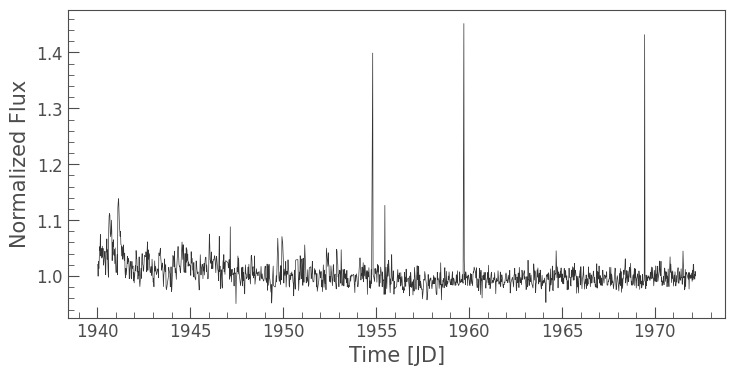

In [6]:
epic = 202059070
folder = "../assets/data/main/k2-variable-campaigns/lightcurves/campaign-0"

files = find_k2varcat_files(epic, folder)
print(files)

stitched_lc = stitch_k2varcat_lightcurve(epic, folder, use_detrended=True)
stitched_lc.plot()


---

In [7]:
!pwd


/Users/wayfinder/Code/fault-in-our-stars/test-code


In [8]:
import pandas as pd


In [9]:
K2VARCAT = pd.read_csv(r"../assets/data/main/k2-variable-campaigns/hlsp_k2varcat_k2_lightcurve_c00-c04_kepler_v2_catalog.csv")


In [10]:
K2VARCAT


,# ID,Campaign,Class,Class Probs (DSCUT,EA,EB,GDOR,Noise,OTHPER,RRab),Anomaly Score
0,202059070,0,Noise,0.004195,0.120507,0.016615,0.005925,0.604636,0.246088,0.002034,0.023891
1,202059073,0,Noise,0.000000,0.000760,0.000037,0.000180,0.851359,0.147664,0.000000,0.003344
2,202059074,0,Noise,0.000086,0.003688,0.000218,0.007253,0.547118,0.441569,0.000067,0.083032
3,202059078,0,Noise,0.000523,0.002839,0.000332,0.000105,0.888648,0.107552,0.000000,0.000000
4,202059080,0,Noise,0.038219,0.082267,0.022758,0.058409,0.614507,0.078915,0.104926,0.136364
...,...,...,...,...,...,...,...,...,...,...,...
68905,211201576,4,OTHPER,0.000779,0.030250,0.003867,0.006026,0.399292,0.559605,0.000182,0.003344
68906,211202722,4,Noise,0.001130,0.066439,0.018303,0.010098,0.613187,0.290660,0.000183,0.003344
68907,211203438,4,Noise,0.003991,0.280059,0.017429,0.017574,0.482890,0.198004,0.000052,0.006711
68908,211203556,4,Noise,0.005440,0.087409,0.009792,0.031328,0.604436,0.261294,0.000302,0.010101


In [11]:
# Remove extra spaces from column names
K2VARCAT.columns = K2VARCAT.columns.str.strip()


In [12]:
K2VARCAT.columns


Index(['# ID', 'Campaign', 'Class', 'Class Probs (DSCUT', 'EA', 'EB', 'GDOR',
       'Noise', 'OTHPER', 'RRab)', 'Anomaly Score'],
      dtype='str')

In [13]:
C_00 = K2VARCAT[K2VARCAT['Campaign'] == 0]


In [14]:
C_00


,# ID,Campaign,Class,Class Probs (DSCUT,EA,EB,GDOR,Noise,OTHPER,RRab),Anomaly Score
0,202059070,0,Noise,0.004195,0.120507,0.016615,0.005925,0.604636,0.246088,0.002034,0.023891
1,202059073,0,Noise,0.000000,0.000760,0.000037,0.000180,0.851359,0.147664,0.000000,0.003344
2,202059074,0,Noise,0.000086,0.003688,0.000218,0.007253,0.547118,0.441569,0.000067,0.083032
3,202059078,0,Noise,0.000523,0.002839,0.000332,0.000105,0.888648,0.107552,0.000000,0.000000
4,202059080,0,Noise,0.038219,0.082267,0.022758,0.058409,0.614507,0.078915,0.104926,0.136364
...,...,...,...,...,...,...,...,...,...,...,...
7743,202140012,0,OTHPER,0.000520,0.016286,0.003464,0.010666,0.132266,0.836630,0.000169,0.010101
7744,202140013,0,OTHPER,0.002259,0.036488,0.007759,0.042130,0.339988,0.571152,0.000224,0.003344
7745,202140059,0,Noise,0.000683,0.009470,0.000673,0.000535,0.777289,0.211217,0.000133,0.041667
7746,202140094,0,Noise,0.001223,0.002817,0.000765,0.000703,0.914259,0.080175,0.000058,0.030928


In [15]:
C_00_folder = "/Users/wayfinder/Code/fault-in-our-stars/assets/data/main/k2-variable-campaigns/lightcurves/campaign-0"
epicIDs = C_00['# ID'].unique()

epicIDs


array([202059070, 202059073, 202059074, ..., 202140059, 202140094,
       202154314], shape=(7748,))

In [16]:
lcs = {}

for id in epicIDs:
    # lcs[id] = stitch_k2varcat_lightcurve(id, C_00_folder, use_detrended=True)
    lc = stitch_k2varcat_lightcurve(id, C_00_folder, use_detrended=True)

    # Extract time, flux, and flux_err arrays from the LightCurve object
    time = lc.time.value.tolist()
    flux = lc.flux.value.tolist()
    flux_err = lc.flux_err.value.tolist() if 'flux_err' in lc.columns else None
    
    # Store the extracted data in the dictionary with EPIC ID as key
    lcs[int(id)] = {
        'time': time,
        'flux': flux,
        'flux_err': flux_err
    }

# lcs


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/lightcurve.py:1154: LightkurveWarning: The light c

In [17]:
# Convert the keys from strings to integers
# lcs = {int(id): lcs[id] for id in lcs}

# Now the keys are integers
print(lcs.keys())


dict_keys([202059070, 202059073, 202059074, 202059078, 202059080, 202059081, 202059082, 202059086, 202059183, 202059188, 202059190, 202059192, 202059193, 202059195, 202059197, 202059198, 202059199, 202059203, 202059204, 202059207, 202059208, 202059210, 202059215, 202059221, 202059222, 202059223, 202059224, 202059229, 202059231, 202059243, 202059291, 202059299, 202059310, 202059312, 202059318, 202059326, 202059327, 202059330, 202059332, 202059333, 202059336, 202059339, 202059343, 202059346, 202059347, 202059348, 202059350, 202059351, 202059352, 202059355, 202059359, 202059360, 202059364, 202059367, 202059373, 202059377, 202059382, 202059388, 202059391, 202059392, 202059393, 202059397, 202059403, 202059406, 202059409, 202059410, 202059414, 202059415, 202059416, 202059418, 202059421, 202059422, 202059428, 202059430, 202059432, 202059433, 202059434, 202059435, 202059501, 202059511, 202059521, 202059522, 202059530, 202059531, 202059532, 202059545, 202059547, 202059552, 202059586, 202059600,

In [18]:
# import json 

# K2_VAR_CAT_JSON = json.dumps(lcs, indent=4)
# print(K2_VAR_CAT_JSON)


In [19]:
df_of_lcs = pd.DataFrame.from_dict(lcs, orient='index')
df_of_lcs.head(5)


,time,flux,flux_err
202059070,"[1940.02801180377, 1940.0484434910104, 1940.06...","[1.0209611654281616, 0.999671220779419, 1.0258...","[0.02067832462489605, 0.019551541656255722, 0...."
202059073,"[1940.0078166502353, 1940.02824824032, 1940.04...","[0.9937425851821899, 0.99190354347229, 0.99378...","[0.003274966264143586, 0.0029797914903610945, ..."
202059074,"[1940.0078458546486, 1940.0487091504256, 1940....","[0.9949902296066284, 0.9948084354400635, 0.995...","[0.0008578745764680207, 0.0009096064022742212,..."
202059078,"[1940.0084669657808, 1940.0288985853185, 1940....","[0.9812511205673218, 0.9826586246490479, 0.979...","[0.013931773602962494, 0.01365430187433958, 0...."
202059080,"[1940.0084856754693, 1940.0289172976845, 1940....","[0.9239972829818726, 0.8829833269119263, 0.904...","[0.08906208723783493, 0.08731886744499207, 0.0..."


In [ ]:
import pandas as pd

# Assuming df_of_lcs and C_00 are already defined

# Change the index of C_00 to '# ID'
C_00.set_index('# ID', inplace=True)

# Merge C_00 with df_of_lcs on the '# ID' field
C_00_LC_DATA = pd.merge(C_00, df_of_lcs, left_index=True, right_index=True)

# Display the merged DataFrame
# print(C_00_LC_DATA.head())


           Campaign   Class  Class Probs (DSCUT        EA        EB      GDOR  \
# ID                                                                            
202059070         0   Noise            0.004195  0.120507  0.016615  0.005925   
202059073         0   Noise            0.000000  0.000760  0.000037  0.000180   
202059074         0   Noise            0.000086  0.003688  0.000218  0.007253   
202059078         0   Noise            0.000523  0.002839  0.000332  0.000105   
202059080         0   Noise            0.038219  0.082267  0.022758  0.058409   

              Noise    OTHPER     RRab)  Anomaly Score  \
# ID                                                     
202059070  0.604636  0.246088  0.002034       0.023891   
202059073  0.851359  0.147664  0.000000       0.003344   
202059074  0.547118  0.441569  0.000067       0.083032   
202059078  0.888648  0.107552  0.000000       0.000000   
202059080  0.614507  0.078915  0.104926       0.136364   

                         

In [22]:
C_00_LC_DATA.head()


,Campaign,Class,Class Probs (DSCUT,EA,EB,GDOR,Noise,OTHPER,RRab),Anomaly Score,time,flux,flux_err
# ID,,,,,,,,,,,,,
202059070,0,Noise,0.004195,0.120507,0.016615,0.005925,0.604636,0.246088,0.002034,0.023891,"[1940.02801180377, 1940.0484434910104, 1940.06...","[1.0209611654281616, 0.999671220779419, 1.0258...","[0.02067832462489605, 0.019551541656255722, 0...."
202059073,0,Noise,0.000000,0.000760,0.000037,0.000180,0.851359,0.147664,0.000000,0.003344,"[1940.0078166502353, 1940.02824824032, 1940.04...","[0.9937425851821899, 0.99190354347229, 0.99378...","[0.003274966264143586, 0.0029797914903610945, ..."
202059074,0,Noise,0.000086,0.003688,0.000218,0.007253,0.547118,0.441569,0.000067,0.083032,"[1940.0078458546486, 1940.0487091504256, 1940....","[0.9949902296066284, 0.9948084354400635, 0.995...","[0.0008578745764680207, 0.0009096064022742212,..."
202059078,0,Noise,0.000523,0.002839,0.000332,0.000105,0.888648,0.107552,0.000000,0.000000,"[1940.0084669657808, 1940.0288985853185, 1940....","[0.9812511205673218, 0.9826586246490479, 0.979...","[0.013931773602962494, 0.01365430187433958, 0...."
202059080,0,Noise,0.038219,0.082267,0.022758,0.058409,0.614507,0.078915,0.104926,0.136364,"[1940.0084856754693, 1940.0289172976845, 1940....","[0.9239972829818726, 0.8829833269119263, 0.904...","[0.08906208723783493, 0.08731886744499207, 0.0..."


In [23]:
C_00_LC_DATA.to_pickle("../assets/data/main/k2-variable-campaigns/C_00_LC_DATA.pkl")
